--- First 5 Rows


,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056



--- Missing Values Check ---
Id           0
Area         0
Bedrooms     0
Bathrooms    0
Floors       0
YearBuilt    0
Location     0
Condition    0
Garage       0
Price        0
dtype: int64

--- Descriptive Statistics ---
                Id         Area     Bedrooms   Bathrooms       Floors  \
count  2000.000000  2000.000000  2000.000000  2000.00000  2000.000000   
mean   1000.500000  2786.209500     3.003500     2.55250     1.993500   
std     577.494589  1295.146799     1.424606     1.10899     0.809188   
min       1.000000   501.000000     1.000000     1.00000     1.000000   
25%     500.750000  1653.000000     2.000000     2.00000     1.000000   
50%    1000.500000  2833.000000     3.000000     3.00000     2.000000   
75%    1500.250000  3887.500000     4.000000     4.00000     3.000000   
max    2000.000000  4999.000000     5.000000     4.00000     3.000000   

         YearBuilt          Price  
count  2000.000000    2000.000000  
mean   1961.446000  537676.855000  
std      

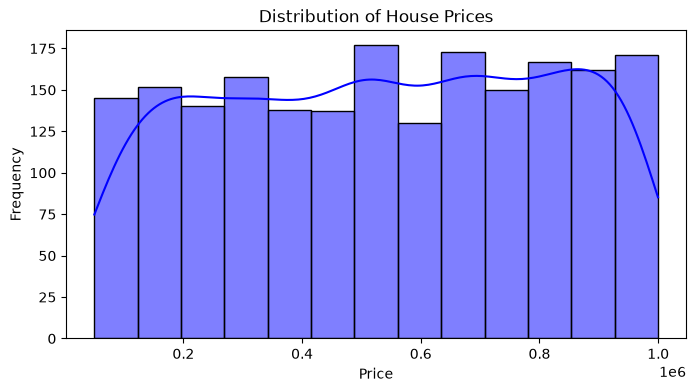

In [16]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('House Price Prediction Dataset.csv')
print('--- First 5 Rows')
display(df.head())
print('\n--- Missing Values Check ---')
print(df.isnull().sum())
print('\n--- Descriptive Statistics ---')
print(df.describe())

plt.figure(figsize=(8, 4))
sns.histplot(df['Price'], kde=True, color='blue')
plt.title('Distribution of House Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

### **1. Dataset Loading & Exploratory DAta Analysis (EDA)**
* **Data Inspection:** Loaded the housing dataset and inspected the  initial structure and data types.
* **Null Check & Statistics:** Checked for missing values using `.isnull().sum()` and analyzed numerical columns via descriptive statistics (`df.describe()`).
* **Target Distribution:** Visualized the distribution of house prices (`Price`) using a histogram with a KDE curve to check for skewness.

In [17]:
num_cols = df.select_dtypes(include=[np.number]).columns
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

 
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    df[col] = df[col].fillna('None')

df = pd.get_dummies(df, drop_first=True)
print("Data shape after One-Hot Encoding:", df.shape)

Data shape after One-Hot Encoding: (2000, 14)


C:\Users\dell\AppData\Local\Temp\ipykernel_31388\2807609050.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns


### **2. Feature Selection, Missing Values & Encoding**
* **Data Cleaning:** Imputed missing values for numerical features using the median and categorical features using default placeholders.
* **Categorical Encoding:** Applied One-Hot Encoding (`pd.get_dummies`) to convert categorical text features into numerical binary format for regression analysis.

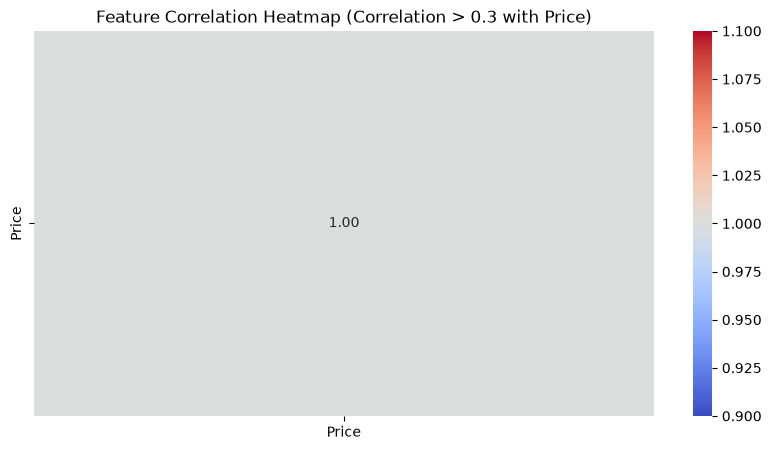

In [18]:
plt.figure(figsize=(10, 5))
correlation_matrix = df.corr()
top_corr_features = correlation_matrix.index[abs(correlation_matrix['Price']) > 0.3]
sns.heatmap(df[top_corr_features].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap (Correlation > 0.3 with Price)')
plt.show()

### **3. Correlation Heatmap Analysis**
* **Feature Correlation** Generated a correlation matrix heatmap focusing on features strongly correlated with the target variable (`Price`).
* **Insight:** Helps identify multicollinearity and select primary independent variables that exert maximum influence on house valuations.

In [19]:
from sklearn.model_selection import train_test_split
x = df.drop('Price', axis=1)
y = df['Price']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
print(f'Training Features Shape: {x_train.shape}')
print(f'Testing Features Shape: {x_test.shape}')

Training Features Shape: (1600, 13)
Testing Features Shape: (400, 13)


### **4. Train/Test Split**
* **Data Partitioning:** Split the cleaned dataset into an 80% training set and a 20% testing set using `train_test_split` to ensure unbiased model evaluation on unseen data.


In [20]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
lr = LinearRegression()
lr.fit(x_train, y_train)
y_pred = lr.predict(x_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print('--- MODEL PERFORMANCE ---')
print(f'Mean Squared Error (MSE): {mse:.2f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.2f}')
print(f'R2 Score: {r2:.4f}')

--- MODEL PERFORMANCE ---
Mean Squared Error (MSE): 78279764120.86
Root Mean Squared Error (RMSE): 279785.21
R2 Score: -0.0062


### **5. Model Training & Evaluation**
* **Linear Regression Training:** Fitted a multiple linear regression model on the training features.
* **Performance Metrics:** Evaluated model predictions using Mean Squared Error (MSE), Root Squared Error (RMSE), and the Coefficient of Determination ($R^2$ score) to measure variance explanation.

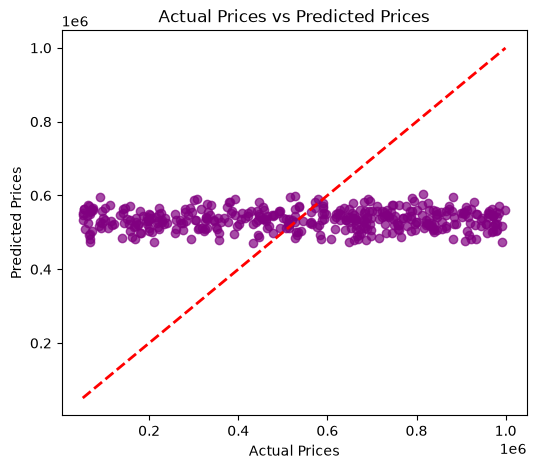

In [21]:
plt.figure(figsize=(6, 5))
plt.scatter(y_test, y_pred, alpha=0.7, color='purple')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Actual Prices vs Predicted Prices')
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.show()

### **6. Actual vs. Predicted Scatter Plot** 
* **Visual Validation:** Plotted actual house prices against predicted values alongside a 45-degree reference line ($y = x$).
* **Insight:** Points clusturing closely around the red dashes line indicate high prediction accuracy and model fit.

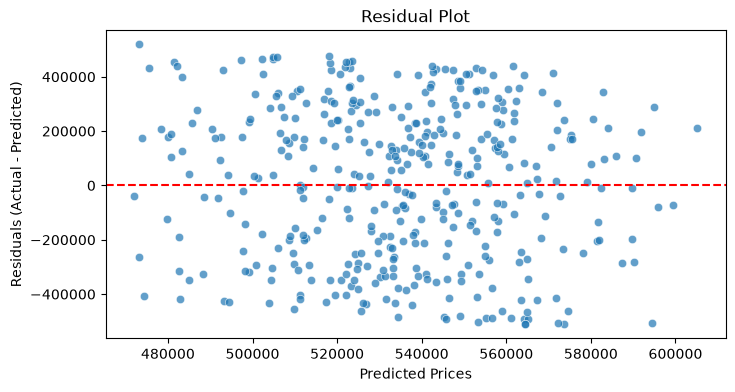

--- Top 5 Positive Impact Features ---


,Feature,Coefficient
9,Condition_Fair,24049.504733
4,Floors,23582.408499
7,Location_Suburban,11110.139855
11,Condition_Poor,4389.783506
12,Garage_Yes,2218.649484



--- Top 5 Negative Impact Features ---


,Feature,Coefficient
1,Area,-0.484192
0,Id,-12.007473
3,Bathrooms,-9835.704344
8,Location_Urban,-12601.589640
10,Condition_Good,-13048.175894


In [22]:
residuals = y_test - y_pred
plt.figure(figsize=(8, 4))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.7)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residual Plot')
plt.xlabel('Predicted Prices')
plt.ylabel('Residuals (Actual - Predicted)')
plt.show()

coefficients = pd.DataFrame({'Feature': x.columns, 'Coefficient': lr.coef_})
coefficients = coefficients.sort_values(by='Coefficient', ascending=False)
print('--- Top 5 Positive Impact Features ---')
display(coefficients.head(5))
print('\n--- Top 5 Negative Impact Features ---')
display(coefficients.tail(5))

### **7. Residual Plot & Coefficient Analysis**
* **Residual Analysis:** Examined the residual scatter plot to varify that errors are randomly distributed around zero, validating the linear regression homoscedasticity assumption.
* **Coefficient Analysis:**  Analyzed regression weights to identify which features exert the positive and negative impacts on house prices.

In [23]:
from sklearn.linear_model import Ridge, Lasso
ridge = Ridge(alpha=1.0)
ridge.fit(x_train, y_train)
ridge_pred = ridge.predict(x_test)
print(f'Ridge R2 Score: {r2_score(y_test, ridge_pred):.4f}')

lasso = Lasso(alpha=100.0)
lasso.fit(x_train, y_train)
lasso_pred = lasso.predict(x_test)
print(f'Lasso R2 Score: {r2_score(y_test, ridge_pred):.4f}')


Ridge R2 Score: -0.0062
Lasso R2 Score: -0.0062


### **8. (Bonus) Regularization: Ridge & Lasso Comparison**
* **Regularization Techniques:** Implemented Ridge and Lasso regression to control model complexity and prevent overfitting from multi-collinear features.
* **Comparative Performance:** Evaluated their $R^2$ scores against the base Linear Regression model to check for performance stability.